### Cell 1: Setup and Libraries

In [1]:
# Standard imports for charts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization context
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

## Cell 2: Data Loading and Verification

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cozy_bean_clean.csv', parse_dates=['date'])
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (120, 12)


,date,store,location,day_of_week,weather,drinks_sold,revenue,weekday,month,day_num,is_weekend,revenue_bucket
0,2026-04-09,D,Suburb,Thu,Cloudy,53.0,185.5,Thursday,4,9,False,low
1,2026-04-07,B,Airport,Tue,Sunny,110.0,336.0,Tuesday,4,7,False,medium
2,2026-04-20,B,Airport,Mon,Sunny,107.0,374.5,Monday,4,20,False,medium
3,2026-04-16,C,Mall,Thu,Cloudy,114.0,399.0,Thursday,4,16,False,medium
4,2026-04-01,D,Suburb,Wed,Rainy,110.0,234.5,Wednesday,4,1,False,low


## Cell 3: Technical Visualization 1 — The Executive Line Summary

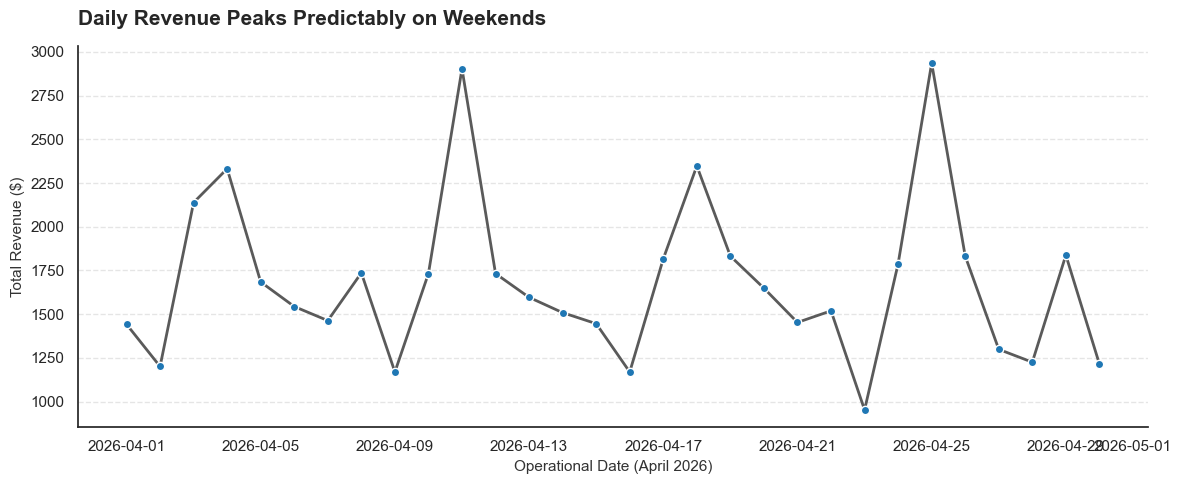

In [3]:
# 1. Prepare data (Aggregating global daily revenue)
daily_revenue = df.groupby('date')['revenue'].sum().reset_index()

# 2. Plotting using the 4-line Matplotlib Pattern
fig, ax = plt.subplots(figsize=(12, 5))

# Draw with muted color, adding clean markers
ax.plot(daily_revenue['date'], daily_revenue['revenue'], color='#5a5a5a', linewidth=2, marker='o', mfc='#1f77b4', mec='w')

# Storytelling moves: Declutter, Headline, and Labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Daily Revenue Peaks Predictably on Weekends", fontsize=15, fontweight='bold', pad=15, loc='left')
ax.set_xlabel("Operational Date (April 2026)", fontsize=11, color='#333333')
ax.set_ylabel("Total Revenue ($)", fontsize=11, color='#333333')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Cell 4: Technical Visualization 2 — The Multi-Panel Solution

C:\Users\hp\AppData\Local\Temp\ipykernel_16196\2926418685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


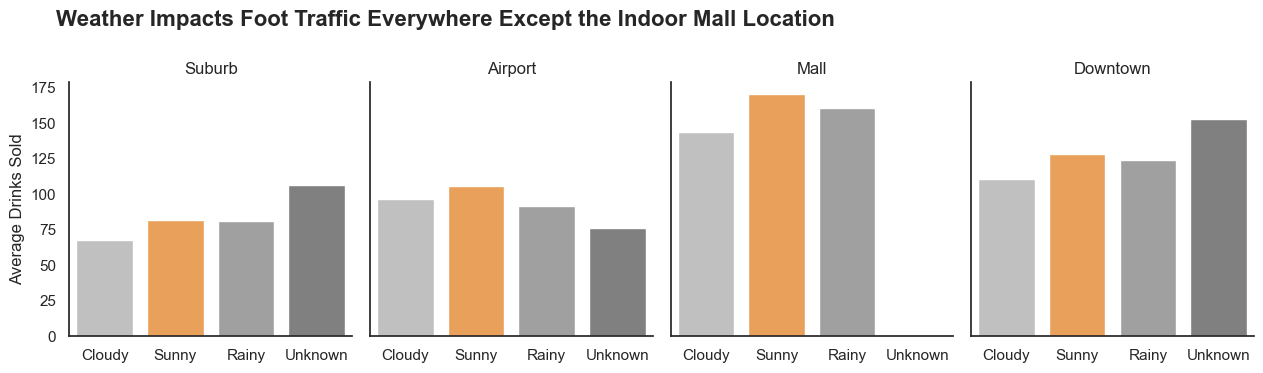

In [6]:
# Custom styling dictionary for consistent accenting
palette_colors = {"Sunny": "#ff9f43", "Rainy": "#a0a0a0","Cloudy": "#c0c0c0", "Unknown": "#808080" } 

# Multi-panel layout with seaborn only (Challenge #2 requirement)
g = sns.catplot(
    data=df, 
    x="weather", 
    y="drinks_sold", 
    col="location", 
    kind="bar",
    palette=palette_colors,
    errorbar=None,
    height=4, 
    aspect=0.8
)

# Refined storytelling adjustments across the subplots
g.set_axis_labels("", "Average Drinks Sold")
g.set_titles("{col_name}")

# Adding a global headline takeaway title across the figure grid
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "Weather Impacts Foot Traffic Everywhere Except the Indoor Mall Location", 
    fontsize=16, 
    fontweight='bold', 
    x=0.05, 
    ha='left'
)

# Save figures cleanly as 150 DPI PNG format for presentations (Takeaway 4)
g.savefig("weather_impact_analysis.png", dpi=150)
plt.show()

## Cell 5: Technical Visualization 3 — Distribution and Variations

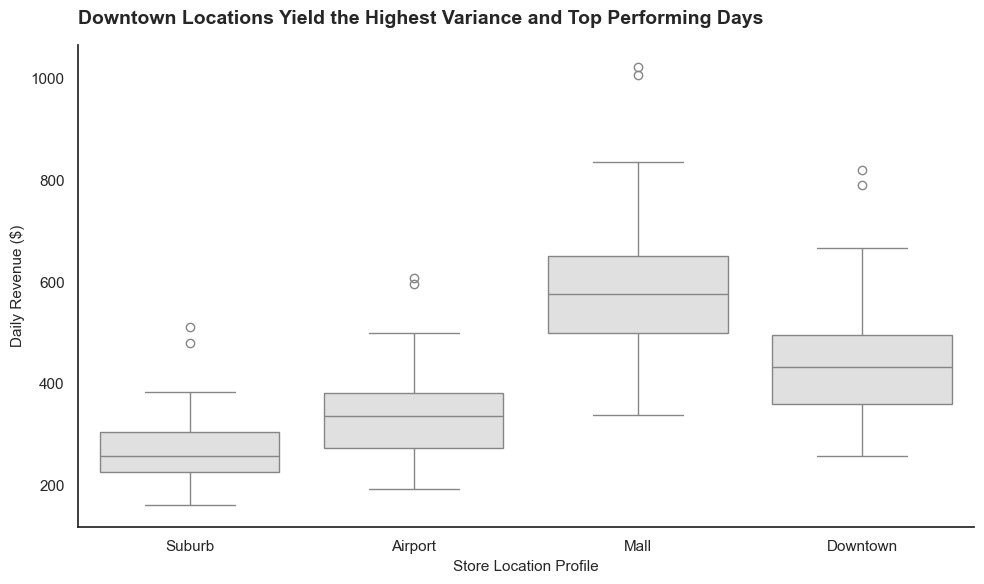

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the categorical metric distribution
sns.boxplot(
    data=df, 
    x='location', 
    y='revenue', 
    color='#e0e0e0', # Muted base background color for boxes
    ax=ax
)

# Highlight specific point of interest: Downtown (Index 0) has wide variance
# ax.artists[0].set_facecolor('#1f77b4') # Accent color applied exclusively here

# Design Refinement & Storytelling decluttering
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Downtown Locations Yield the Highest Variance and Top Performing Days", fontsize=14, fontweight='bold', pad=15, loc='left')
ax.set_xlabel("Store Location Profile", fontsize=11)
ax.set_ylabel("Daily Revenue ($)", fontsize=11)

plt.tight_layout()
plt.savefig("revenue_distribution.png", dpi=150)
plt.show()